# **Household hourly energy demand forecast**

### 0. Imports 

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### 1. Upload data & Parsing

In [88]:
# Read the data
df = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)


In [89]:
print(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB
None


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [90]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.700,3.800,0.000,0.000,0.0
2075258,26/11/2010,21:02:00,0.932,0.000,239.550,3.800,0.000,0.000,0.0


In [91]:
# parsing --> date + time

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

# set time index
df = df.set_index("Datetime")
df = df.sort_index()

# Convert the numeric columns into floats
numeric_cols = df.columns.difference(["Date", "Time"])

df[numeric_cols] = df[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)

# check
print(df.info())
df.tail()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 158.3+ MB
None


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2010-11-26 20:58:00,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2010-11-26 20:59:00,26/11/2010,20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0
2010-11-26 21:00:00,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2010-11-26 21:01:00,26/11/2010,21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2010-11-26 21:02:00,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


### 2. Missing data handling

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


<Axes: xlabel='Datetime'>

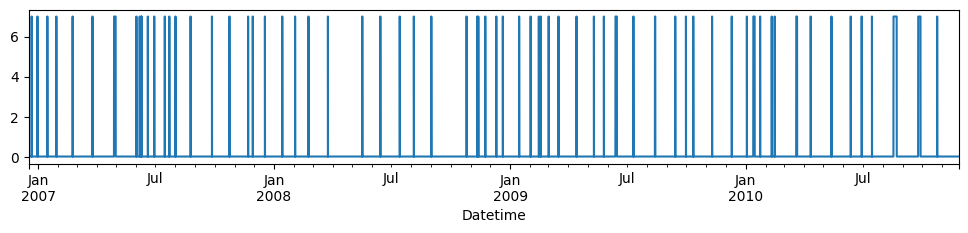

In [92]:
# check missing data
print(df.isnull().sum())

# plot missing data distribution
(df.isna().sum(axis=1)
 .plot(figsize=(12, 2)))

In [93]:
# 1. Identify rows with at least one NaN
nan_mask = df.isna().any(axis=1)

# 2. Find consecutive blocks
# creates a group each time we change state (NaN -> not NaN or viceversa)
groups = (nan_mask != nan_mask.shift()).cumsum()

# 3. Counts the length of each block of NaN
nan_block_lengths = nan_mask.groupby(groups).sum()

# 4. Max, min, mean, median
max_nan_run = nan_block_lengths.max()
mean_nan_run = nan_block_lengths.mean()
median_nan_run = nan_block_lengths.median()

# 5. Beginning date and ending date of the longest block
longest_block = nan_mask.groupby(groups).apply(lambda x: x.index if x.sum() == max_nan_run else None).dropna().iloc[0]

print(f"Longest consecutive NaN period: {max_nan_run} rows")
print(f"From {longest_block[0]} to {longest_block[-1]}")
print(f"\nAverage consecutive NaN rows: {mean_nan_run:.2f}")
print(f"Median consecutive NaN rows: {median_nan_run}")


Longest consecutive NaN period: 7226 rows
From 2010-08-17 21:02:00 to 2010-08-22 21:27:00

Average consecutive NaN rows: 181.67
Median consecutive NaN rows: 0.0


In [94]:
# time interpolation

df['was_interpolated'] = nan_mask

df = df.interpolate(method="time")
print(df.isna().sum())

# Numero totale di righe che contenevano NaN
num_interpolated = df['was_interpolated'].sum()
print(f"Number of rows that were interpolated: {num_interpolated}")

df.info()
df.head()


C:\Users\Matteo\AppData\Local\Temp\ipykernel_31264\3851704155.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method="time")


Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
was_interpolated         0
dtype: int64
Number of rows that were interpolated: 25979
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
 9   was_interpolated       bool   
dtypes: bool(1), float64(7), object(2)
memory usage: 160.3+ MB


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,was_interpolated
Datetime,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,False
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,False
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,False
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,False
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,False


Missing values account for approximately 1.25% of the dataset and affect all measurement variables simultaneously.

Missing observations are distributed over time, mostly as isolated points or short consecutive intervals, with the longest consecutive missing period spanning 7,226 rows (from 2010-08-17 21:02:00 to 2010-08-22 21:27:00). The average length of missing blocks is 181.67 rows, and the median is 0 rows, indicating that most missing values are isolated.

Given the regular time index and the limited extent of missingness, time-based linear interpolation was applied to obtain a complete time series. Additionally, a boolean flag column `was_interpolated` was added to indicate which rows originally contained missing values.


### 3. Feature engineering


Formula used for conversion:

    `Energy (Wh)= Power (kW)×60/1000​ per min`

In [95]:
# 1) Conversion Power (kW per min) → Energy (Wh per min)
# Global_active_power & Global_reactive_power in kW → Wh per min
df['Global_active_energy'] = df['Global_active_power'] * 1000 / 60
df['Global_reactive_energy'] = df['Global_reactive_power'] * 1000 / 60

# 2) Remaining_submetering
df['Remaining_submetering'] = df['Global_active_energy'] - (
    df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
)

# 3) Other temporal features 
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek   # 0=Monday, 6=Sunday
df['Weekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

# Season 
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df.index.month.map(get_season)

# Reorganise columns
order = [
    "Date",
    "Time",
    "Hour",
    "DayOfWeek",
    "Weekend",
    "Season",
    "Global_active_power",
    "Global_active_energy",
    "Global_reactive_power",
    "Global_reactive_energy",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "Remaining_submetering",
    "was_interpolated"
]


df = df[order]


# check
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Date                    object 
 1   Time                    object 
 2   Hour                    int32  
 3   DayOfWeek               int32  
 4   Weekend                 int64  
 5   Season                  object 
 6   Global_active_power     float64
 7   Global_active_energy    float64
 8   Global_reactive_power   float64
 9   Global_reactive_energy  float64
 10  Voltage                 float64
 11  Global_intensity        float64
 12  Sub_metering_1          float64
 13  Sub_metering_2          float64
 14  Sub_metering_3          float64
 15  Remaining_submetering   float64
 16  was_interpolated        bool   
dtypes: bool(1), float64(10), int32(2), int64(1), object(3)
memory usage: 255.3+ MB
None


,Date,Time,Hour,DayOfWeek,Weekend,Season,Global_active_power,Global_active_energy,Global_reactive_power,Global_reactive_energy,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Remaining_submetering,was_interpolated
Datetime,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,17,5,1,Winter,4.216,70.266667,0.418,6.966667,234.84,18.4,0.0,1.0,17.0,52.266667,False
2006-12-16 17:25:00,16/12/2006,17:25:00,17,5,1,Winter,5.360,89.333333,0.436,7.266667,233.63,23.0,0.0,1.0,16.0,72.333333,False
2006-12-16 17:26:00,16/12/2006,17:26:00,17,5,1,Winter,5.374,89.566667,0.498,8.300000,233.29,23.0,0.0,2.0,17.0,70.566667,False
2006-12-16 17:27:00,16/12/2006,17:27:00,17,5,1,Winter,5.388,89.800000,0.502,8.366667,233.74,23.0,0.0,1.0,17.0,71.800000,False
2006-12-16 17:28:00,16/12/2006,17:28:00,17,5,1,Winter,3.666,61.100000,0.528,8.800000,235.68,15.8,0.0,1.0,17.0,43.100000,False


In [ ]:
# Save by-minute version 
df_byminute = df.copy()

# Hourly aggregation
df = df.resample("H").agg({
    # Energy variables (sum)
    'Global_active_energy': 'sum',
    'Global_reactive_energy': 'sum',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
    'Remaining_submetering': 'sum',

    # Physical averages
    'Voltage': 'mean',
    'Global_intensity': 'mean',

    # Temporal / categorical
    'Date': 'first',
    'Time': 'first',
    'Hour': 'first',
    'DayOfWeek': 'first',
    'Weekend': 'first',
    'Season': 'first',

    # Data quality flag
    'was_interpolated': 'any'
})


# Conversion Wh → kWh for standard interpretation
energy_cols = [
    "Global_active_energy",
    "Global_reactive_energy",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "Remaining_submetering"
]

for col in energy_cols:
    df[col + "_kWh"] = df[col] / 1000

# Renaming sub-metering for clarity
df = df.rename(columns={
    "Sub_metering_1_kWh": "kitchen_energy_kwh",
    "Sub_metering_2_kWh": "laundry_energy_kwh",
    "Sub_metering_3_kWh": "climate_energy_kwh",
    "Remaining_submetering_kWh": "other_energy_kwh",
    "Global_active_energy_kWh": "active_energy_kwh",
    "Global_reactive_energy_kWh": "reactive_energy_kwh"
})

# Reorganise columns
order = [
    "Date",
    "Time",
    "Hour",
    "DayOfWeek",
    "Weekend",
    "Season",
    "active_energy_kwh",
    "reactive_energy_kwh",
    "Voltage",
    "Global_intensity",
    "kitchen_energy_kwh",
    "laundry_energy_kwh",
    "climate_energy_kwh",
    "other_energy_kwh",
    "was_interpolated"
]


df = df[order]

# Columns names in lowercase
df.columns = [col.lower() for col in df.columns]

# check
print(df.info())
df.head()

C:\Users\Matteo\AppData\Local\Temp\ipykernel_31264\3627528919.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("H").agg({


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 34589 non-null  object 
 1   time                 34589 non-null  object 
 2   hour                 34589 non-null  int32  
 3   dayofweek            34589 non-null  int32  
 4   weekend              34589 non-null  int64  
 5   season               34589 non-null  object 
 6   active_energy_kwh    34589 non-null  float64
 7   reactive_energy_kwh  34589 non-null  float64
 8   voltage              34589 non-null  float64
 9   global_intensity     34589 non-null  float64
 10  kitchen_energy_kwh   34589 non-null  float64
 11  laundry_energy_kwh   34589 non-null  float64
 12  climate_energy_kwh   34589 non-null  float64
 13  other_energy_kwh     34589 non-null  float64
 14  was_interpolated     34589 non-null  bool  

,date,time,hour,dayofweek,weekend,season,active_energy_kwh,reactive_energy_kwh,voltage,global_intensity,kitchen_energy_kwh,laundry_energy_kwh,climate_energy_kwh,other_energy_kwh,was_interpolated
Datetime,,,,,,,,,,,,,,,
2006-12-16 17:00:00,16/12/2006,17:24:00,17,5,1,Winter,2.533733,0.137400,234.643889,18.100000,0.0,0.019,0.607,1.907733,False
2006-12-16 18:00:00,16/12/2006,18:00:00,18,5,1,Winter,3.632200,0.080033,234.580167,15.600000,0.0,0.403,1.012,2.217200,False
2006-12-16 19:00:00,16/12/2006,19:00:00,19,5,1,Winter,3.400233,0.085233,233.232500,14.503333,0.0,0.086,1.001,2.313233,False
2006-12-16 20:00:00,16/12/2006,20:00:00,20,5,1,Winter,3.268567,0.075100,234.071500,13.916667,0.0,0.000,1.007,2.261567,False
2006-12-16 21:00:00,16/12/2006,21:00:00,21,5,1,Winter,3.056467,0.076667,237.158667,13.046667,0.0,0.025,1.033,1.998467,False


### 4. Exploratory Data Analysis

In [99]:
# descriptive statistics
num_var = df[['active_energy_kwh', 'reactive_energy_kwh', 'voltage', 
              'global_intensity', 'kitchen_energy_kwh', 'laundry_energy_kwh',
              'climate_energy_kwh', 'other_energy_kwh']]

num_var.describe()

,active_energy_kwh,reactive_energy_kwh,voltage,global_intensity,kitchen_energy_kwh,laundry_energy_kwh,climate_energy_kwh,other_energy_kwh
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.090237,0.123644,240.832682,4.621615,0.066566,0.077351,0.386528,0.559792
std,0.894216,0.067069,3.001576,3.743583,0.211103,0.250098,0.440442,0.494604
min,0.046733,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000,0.046733
25%,0.342867,0.077933,239.178167,1.516667,0.000000,0.000000,0.039000,0.261833
50%,0.803216,0.107133,240.974667,3.423333,0.000000,0.020000,0.099000,0.348000
75%,1.578700,0.149500,242.689000,6.603333,0.000000,0.039000,0.845000,0.669500
max,6.560533,0.774333,251.902000,28.383333,2.902000,2.786000,1.471470,3.890233


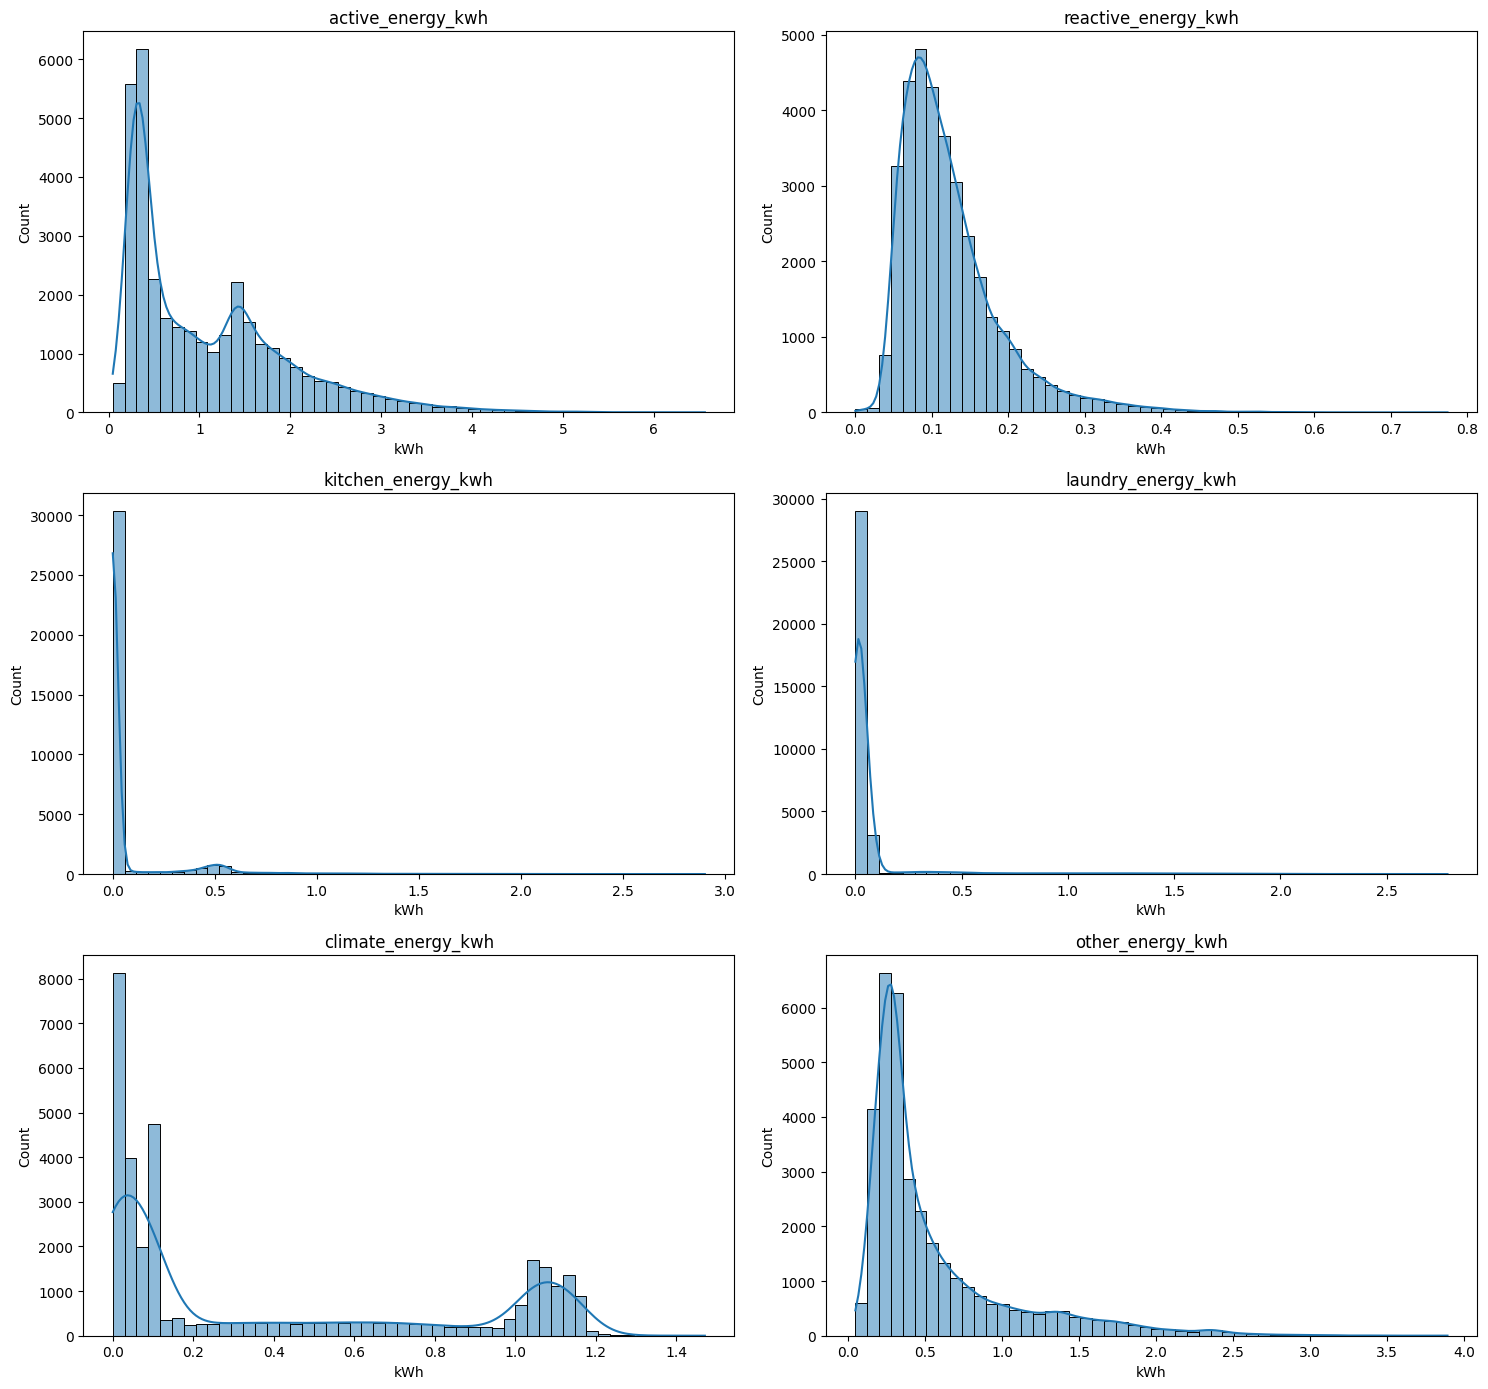

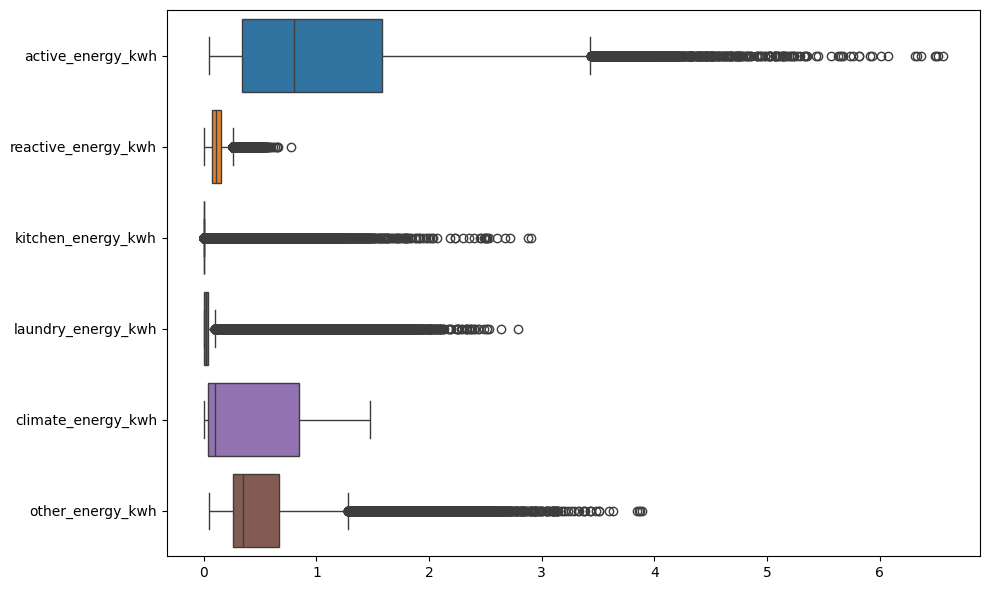

In [127]:
# distribution of energy measurements 
energy_cols = [
    "active_energy_kwh", "reactive_energy_kwh",
    "kitchen_energy_kwh", "laundry_energy_kwh",
    "climate_energy_kwh", "other_energy_kwh"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(energy_cols):
    sns.histplot(
        df[col],
        bins=50,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("kWh")

plt.tight_layout()
plt.show()

# boxplots of energy variables
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df[energy_cols],
    orient="h"
)
plt.tight_layout()
plt.show()


The distribution of all energy-related variables is strongly right-skewed and clearly deviates from normality.
Most observations are concentrated at low consumption levels, while a limited number of hours exhibit very high energy usage, resulting in long right tails.

Several sub-metering variables are zero-inflated, reflecting the intermittent usage of specific appliances (e.g., kitchen, laundry, climate systems), which are inactive during most hours and produce consumption spikes only when in use.

Voltage, in contrast, shows limited variability and a stable distribution over time.

The presence of extreme values is consistent with genuine high-consumption events rather than data errors.

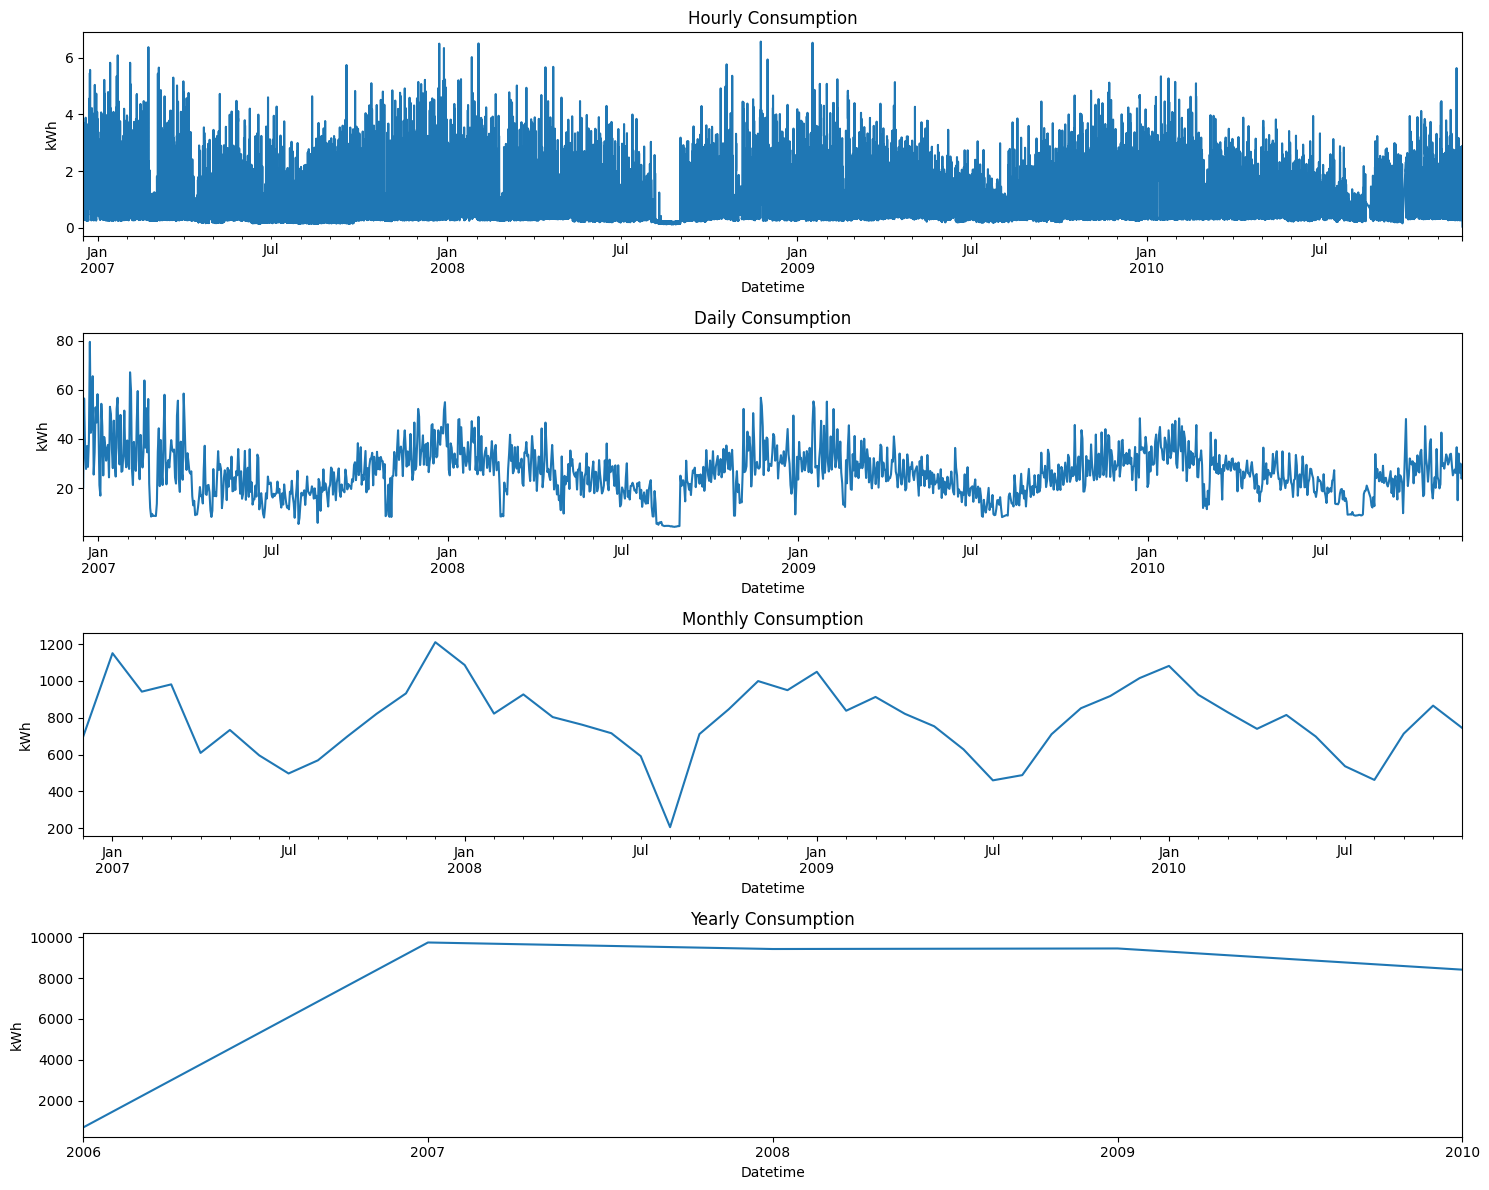

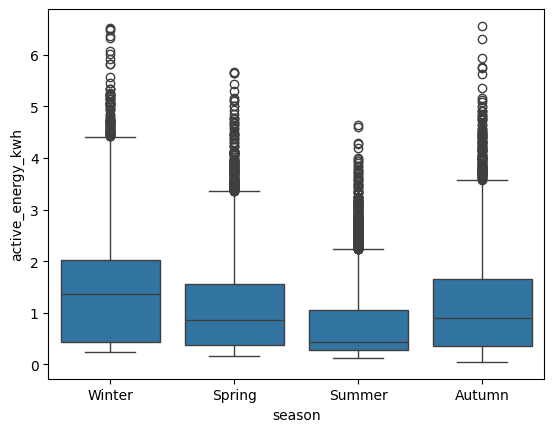

In [122]:
# Active energy consumption over time

# create datasets for ploting
df_daily = df['active_energy_kwh'].resample("D").sum()  # daily
df_monthly = df['active_energy_kwh'].resample("ME").sum() # monthly
df_yearly = df['active_energy_kwh'].resample("YE").sum()   # yearly

# plots
fig, axes = plt.subplots(4, 1, figsize=(15,12), sharex=False)

df['active_energy_kwh'].plot(ax=axes[0], title="Hourly Consumption")
df_daily.plot(ax=axes[1], title="Daily Consumption")
df_monthly.plot(ax=axes[2], title="Monthly Consumption")
df_yearly.plot(ax=axes[3], title="Yearly Consumption")

for ax in axes:
    ax.set_ylabel("kWh")

plt.tight_layout()
plt.show()


# boxplot seasonality
sns.boxplot(x='season', y='active_energy_kwh', data=df)
plt.show()




The plots show high hourly and daily variability in active energy consumption, reflecting short-term fluctuations in household electricity usage. 

At the monthly aggregation level a clear seasonal pattern can be seen, with higher energy consumption during the winter months and lower consumption in summer. This pattern is also confirmed by the distribution in the boxplot above.  

On a yearly basis, total energy consumption seems to be relatively stable across the observation period. The apparent increase from 2006 and 2007 is not representative of real increase in consumption as data for 2006 only include the last 14 days of the year.

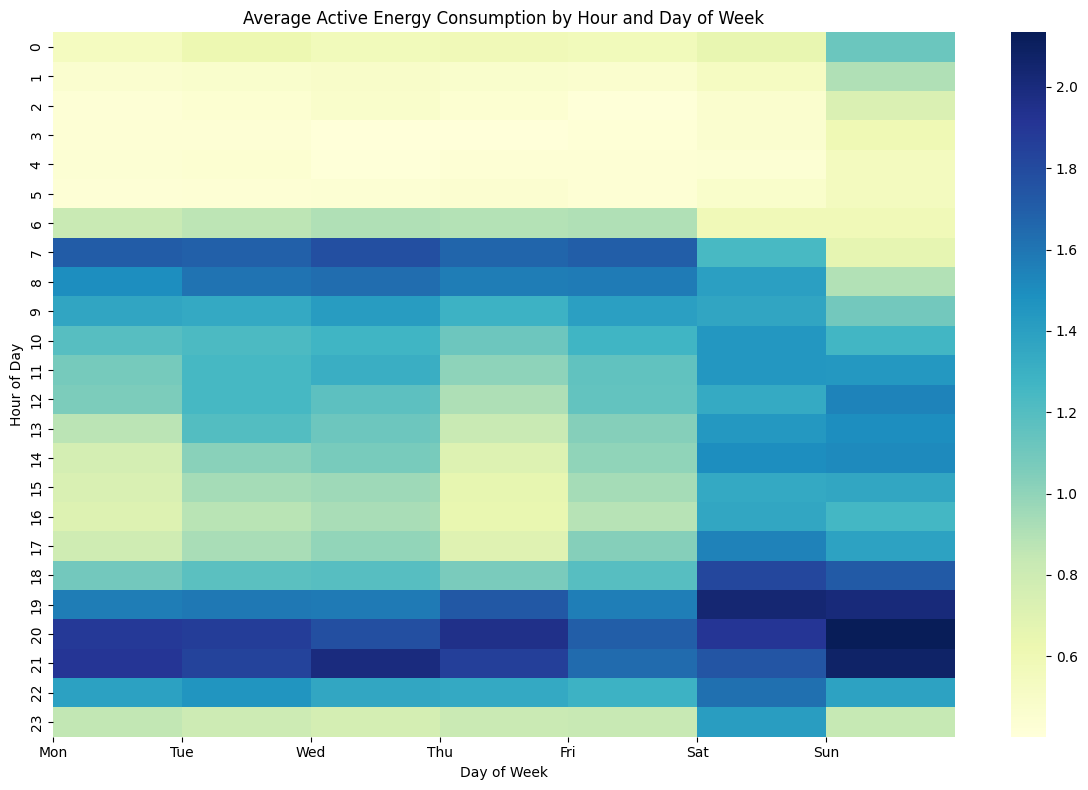

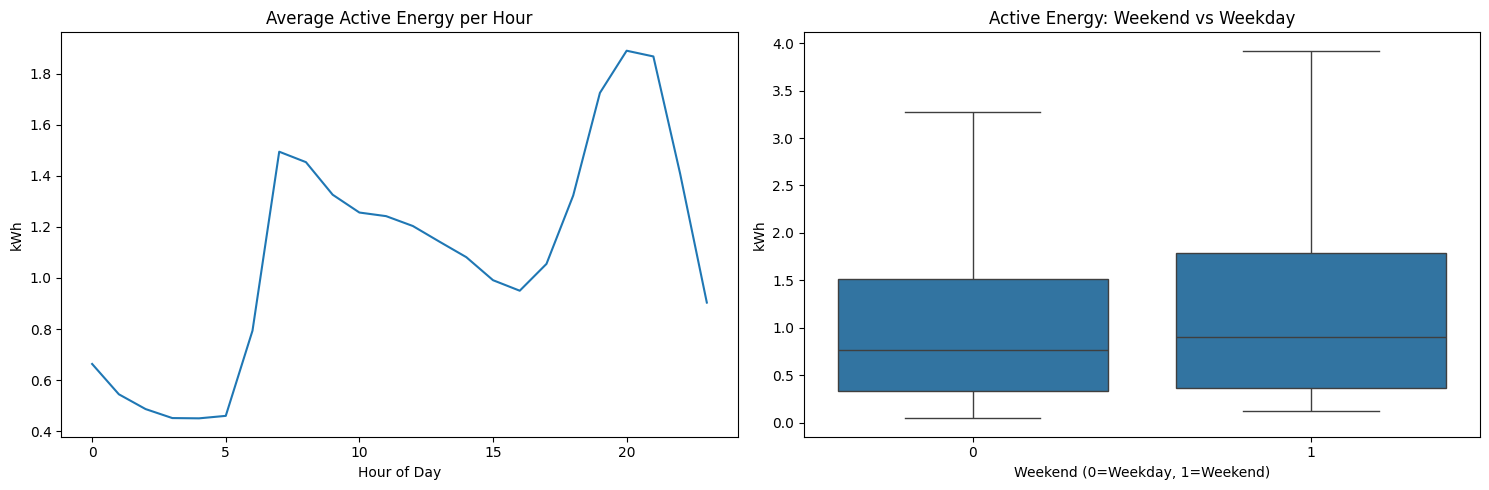

In [128]:
# Heatmap: hour vs day of week
plt.figure(figsize=(12, 8))

pivot = df.pivot_table(
    index='hour',
    columns='dayofweek',
    values='active_energy_kwh',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Average Active Energy Consumption by Hour and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.xticks(
    ticks=range(7),
    labels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Average hourly profile
df.groupby('hour')['active_energy_kwh'].mean().plot(
    ax=axes[0]
)
axes[0].set_title("Average Active Energy per Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("kWh")

# Weekend vs Weekday boxplot
sns.boxplot(
    x='weekend',
    y='active_energy_kwh',
    data=df,
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title("Active Energy: Weekend vs Weekday")
axes[1].set_xlabel("Weekend (0=Weekday, 1=Weekend)")
axes[1].set_ylabel("kWh")

plt.tight_layout()
plt.show()




The heatmap reveals differences in electricity consumption behavior between weekends and working days.

Across all days of the week, consistently low average consumption levels are observed during nighttime hours, corresponding to typical sleeping schedules. Notable differences emerge in the early morning (~ 6–8 a.m.), where energy consumption is higher on weekdays, likely reflecting school and work-related activities.

During weekends, energy consumption appears more evenly distributed throughout the day, whereas on weekdays relatively lower consumption levels are observed during early afternoon hours (approximately 13–17). Peak consumption is concentrated in the evening hours (19–21), with the highest levels observed on Sundays. These patterns are further confirmed by the average hourly consumption profile shown in the line plot.

The boxplot comparison highlights a slightly higher median energy consumption on weekends compared to working days, as well as increased variability.
 

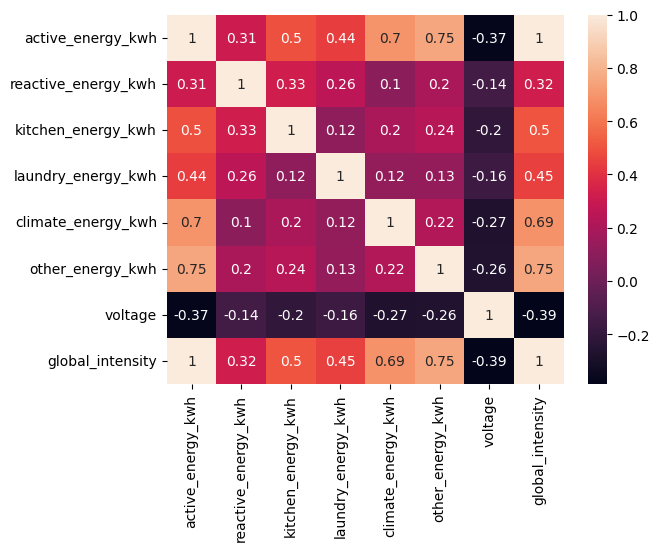

In [129]:
# correlation heatmap
sns.heatmap(df[energy_cols + ['voltage','global_intensity']].corr(), annot=True)
plt.show()


The correlation heatmap highlights several meaningful relationships among the variables.

- Voltage exhibits moderate negative correlations with all energy-related variables. This behavior is expected, as higher voltage levels typically correspond to lower current intensity for a given power demand, resulting in an inverse relationship with energy consumption.

- Global intensity and total active energy are perfectly positively correlated (corr = 1). The two variables represent the same underlying physical quantity expressed through closely related measurements, giving redundant information. 

- All energy consumption components expressed in kWh are positively correlated with each other. In particular, climate energy consumption (corr = 0.69) and other energy consumption (corr = 0.75) show strong correlations with the target variable active energy. This suggests that these components represent a substantial share of total household energy usage and are key drivers of overall consumption.

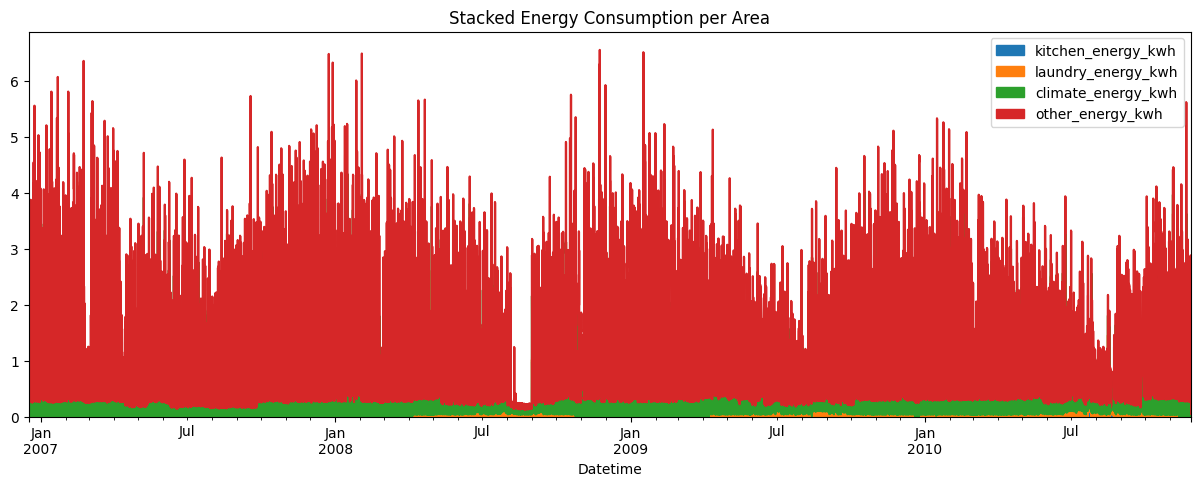

In [ ]:
# stacked energy consumption plot
df[['kitchen_energy_kwh','laundry_energy_kwh','climate_energy_kwh','other_energy_kwh']].plot.area(figsize=(15,5))
plt.title("Stacked Energy Consumption per Area")
plt.show()


The stacked area plot illustrates the contribution of different household areas to total energy consumption over time. Kitchen and laundry appliances account for only a small fraction of overall energy usage, reflecting their intermittent and short-duration operation.

Climate-related consumption represents a larger share compared to kitchen and laundry, likely due to the use of energy-intensive appliances such as electric water heaters and air conditioning.

However, the largest contribution to total energy consumption originates from the remaining household areas, which include appliances and electrical loads not explicitly captured by the sub-metering variables. This component consistently dominates overall energy usage and plays a key role in determining total demand of energy.

### 5. Feature selection & temporal encoding for modeling

